# Multiclass Classification with Softmax

In this notebook, we'll learn how to extend our neural networks from binary classification (2 classes) to multiclass classification (3+ classes). We'll introduce the **softmax function** and **categorical cross-entropy loss**, then apply these concepts to build a simple classifier.

## Motivation: The Limitation of Binary Classification

So far, we've learned how to perform binary classification - distinguishing between two classes (e.g., cat vs dog, spam vs not spam). We used:
- **Sigmoid activation**: Outputs a single probability $P(y=1)$
- **Binary cross-entropy loss**: Measures how well we predict two classes

But what if we have **more than two classes**? Consider the MNIST dataset:

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 495kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.98MB/s]


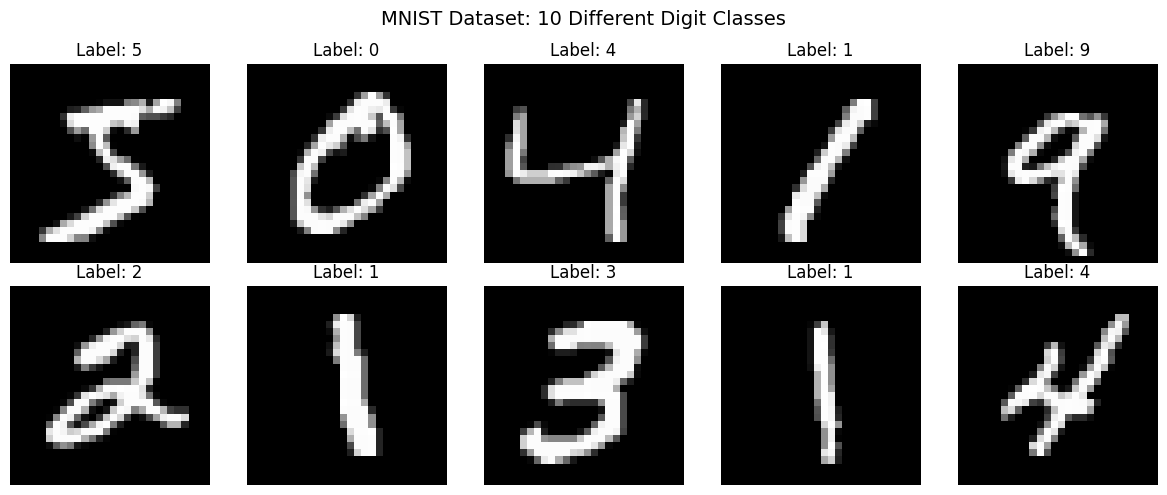

Number of classes: 10
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Visualize some examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    image, label = mnist_train[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('MNIST Dataset: 10 Different Digit Classes', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Number of classes: {len(mnist_train.classes)}")
print(f"Classes: {mnist_train.classes}")

**The Problem**: MNIST has **10 classes** (digits 0-9), not just 2!

With sigmoid, we can only output a single probability. How do we output probabilities for 10 different classes? We need:
- A way to output **multiple probabilities** (one for each class)
- These probabilities should **sum to 1** (total probability = 100%)
- Each probability should be **between 0 and 1**

This is where **softmax** comes in.

## The Softmax Function: Sigmoid's Generalization

### Intuition

Think of softmax as a "voting system" for multiple classes:
1. Each class gets a **score** (called a "logit")
2. Higher scores mean the model is more confident in that class
3. Softmax **converts these scores into probabilities** that sum to 1

### Mathematical Definition

Given a vector of scores (logits) $\mathbf{z} = [z_1, z_2, ..., z_K]$ for $K$ classes, softmax computes:

$$\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

**Key properties**:
- Output is always between 0 and 1: $0 \leq \text{softmax}(z_i) \leq 1$
- Outputs sum to 1: $\sum_{i=1}^{K} \text{softmax}(z_i) = 1$
- Larger logits get larger probabilities (order is preserved)

**Connection to Sigmoid**: For binary classification (K=2), softmax reduces to sigmoid!

## Softmax in Code: Seeing the Transformation

Let's implement softmax and see how it converts arbitrary numbers into a probability distribution.

In [2]:
def softmax_manual(logits):
    """
    Manual implementation of softmax for educational purposes.

    Args:
        logits: Tensor of shape (num_classes,)
    Returns:
        probabilities: Tensor of shape (num_classes,)
    """
    exp_logits = torch.exp(logits)  # Exponentiate each logit
    sum_exp = exp_logits.sum()       # Sum all exponentials
    probabilities = exp_logits / sum_exp  # Normalize
    return probabilities

# Example: 4 classes with different logits (raw scores)
logits = torch.tensor([2.0, 1.0, 0.1, 3.0])

print("Input logits (raw scores):")
print(logits)
print(f"\nThese are just numbers - they can be negative, > 1, and don't sum to 1.")
print(f"Sum of logits: {logits.sum():.3f}")

Input logits (raw scores):
tensor([2.0000, 1.0000, 0.1000, 3.0000])

These are just numbers - they can be negative, > 1, and don't sum to 1.
Sum of logits: 6.100


In [3]:
# Apply softmax
probabilities = softmax_manual(logits)

print("\nAfter softmax (probabilities):")
print(probabilities)
print(f"\nSum of probabilities: {probabilities.sum():.6f}")
print(f"All values between 0 and 1: {(probabilities >= 0).all() and (probabilities <= 1).all()}")


After softmax (probabilities):
tensor([0.2361, 0.0869, 0.0353, 0.6418])

Sum of probabilities: 1.000000
All values between 0 and 1: True


**Observe**:
- The logits were arbitrary numbers (0.1, 1.0, 2.0, 3.0)
- After softmax, we get valid probabilities that sum to 1
- The highest logit (3.0) gets the highest probability

Let's visualize this transformation:

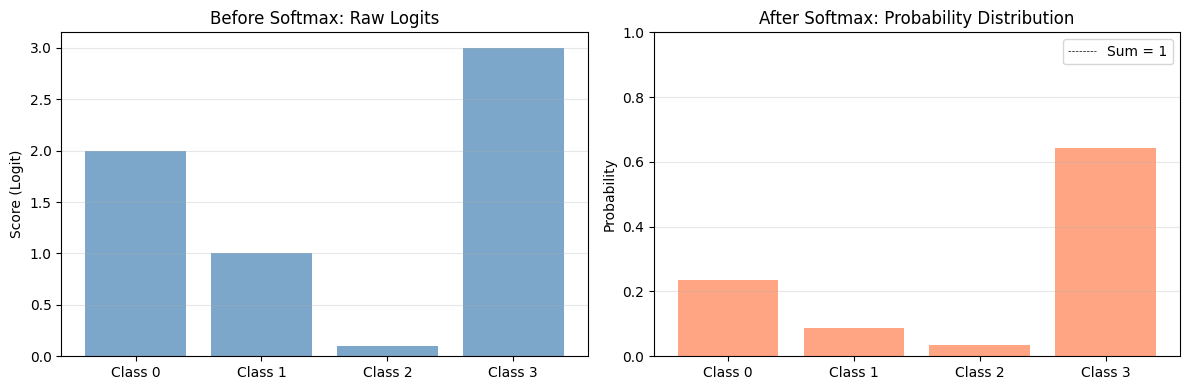

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot logits
classes = ['Class 0', 'Class 1', 'Class 2', 'Class 3']
ax1.bar(classes, logits.numpy(), color='steelblue', alpha=0.7)
ax1.set_ylabel('Score (Logit)')
ax1.set_title('Before Softmax: Raw Logits')
ax1.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
ax1.grid(axis='y', alpha=0.3)

# Plot probabilities
ax2.bar(classes, probabilities.numpy(), color='coral', alpha=0.7)
ax2.set_ylabel('Probability')
ax2.set_title('After Softmax: Probability Distribution')
ax2.set_ylim([0, 1])
ax2.axhline(y=1, color='k', linestyle='--', linewidth=0.5, label='Sum = 1')
ax2.grid(axis='y', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

### Property: Order Preservation

One crucial property of softmax is that it **preserves the order** of the logits. If logit $z_i > z_j$, then $\text{softmax}(z_i) > \text{softmax}(z_j)$.

This means the class with the highest logit will always have the highest probability!

In [5]:
# Let's verify order preservation
print("Original logits (sorted indices):", torch.argsort(logits, descending=True))
print("Probabilities (sorted indices):", torch.argsort(probabilities, descending=True))
print("\nThe order is preserved! Class 3 has the highest score in both.")

# This means for prediction, we can use argmax on either logits or probabilities
print(f"\nPredicted class (argmax of logits): {torch.argmax(logits)}")
print(f"Predicted class (argmax of probabilities): {torch.argmax(probabilities)}")

Original logits (sorted indices): tensor([3, 0, 1, 2])
Probabilities (sorted indices): tensor([3, 0, 1, 2])

The order is preserved! Class 3 has the highest score in both.

Predicted class (argmax of logits): 3
Predicted class (argmax of probabilities): 3


### 🔧 Mini-Exercise 1: Experimenting with Softmax

**TODO**: Create a new logit vector and observe how softmax behaves:
1. What happens if all logits are equal? (e.g., `[1.0, 1.0, 1.0, 1.0]`)
2. What happens if one logit is much larger than others? (e.g., `[0.3, 1.0, 10.0, 2.5]`)
3. What happens with negative logits? (e.g., `[-2.0, -1.0, 0.0, 1.0]`)

⏱️ ~5 minutes

In [ ]:
# TODO: Experiment with different logit values


## PyTorch's Built-in Softmax

PyTorch provides `torch.nn.functional.softmax()` which is numerically stable (handles very large/small numbers better).

In [6]:
import torch.nn.functional as F

# Using PyTorch's softmax
logits = torch.tensor([2.0, 1.0, 0.1, 3.0])
probabilities_pytorch = F.softmax(logits, dim=0)  # dim=0 means apply softmax along this dimension

print("Our manual softmax:", softmax_manual(logits))
print("PyTorch softmax:    ", probabilities_pytorch)
print("\nThey match!")

Our manual softmax: tensor([0.2361, 0.0869, 0.0353, 0.6418])
PyTorch softmax:     tensor([0.2361, 0.0869, 0.0353, 0.6418])

They match!


## From Binary to Categorical Cross-Entropy

Now that we can output probabilities for multiple classes, we need a loss function to train our model.

### Binary Cross-Entropy (Review)

For binary classification with true label $y \in \{0, 1\}$ and predicted probability $\hat{y}$:

$$\text{BCE} = -[y \log(\hat{y}) + (1-y) \log(1-\hat{y})]$$

- If $y=1$: only the first term $-\log(\hat{y})$ is active
- If $y=0$: only the second term $-\log(1-\hat{y})$ is active

### Categorical Cross-Entropy (Generalization)

For multiclass classification with $K$ classes, true label $y \in \{0, 1, ..., K-1\}$, and predicted probabilities $\hat{\mathbf{y}} = [\hat{y}_0, \hat{y}_1, ..., \hat{y}_{K-1}]$:

$$\text{CCE} = -\sum_{i=0}^{K-1} \mathbb{1}_{y=i} \log(\hat{y}_i)$$

where $\mathbb{1}_{y=i}$ is an indicator function (1 if $y=i$, else 0).

**Key insight**: Only the term corresponding to the **true class** is active! All other terms are multiplied by 0.

If the true class is $y=2$:
$$\text{CCE} = -\log(\hat{y}_2)$$

Let's see this in code:

In [7]:
# Example: True class is 3 (index 3)
true_class = 3
predicted_probs = torch.tensor([0.1, 0.2, 0.05, 0.65])  # Model's predicted probabilities

print("Predicted probabilities for each class:")
for i, prob in enumerate(predicted_probs):
    marker = " <-- TRUE CLASS" if i == true_class else ""
    print(f"  Class {i}: {prob:.3f}{marker}")

# Manual categorical cross-entropy calculation
loss_manual = -torch.log(predicted_probs[true_class])
print(f"\nCategorical Cross-Entropy Loss: {loss_manual:.4f}")
print(f"This is just: -log({predicted_probs[true_class]:.3f}) = {loss_manual:.4f}")
print(f"\nNotice: We only care about the probability assigned to the TRUE class!")

Predicted probabilities for each class:
  Class 0: 0.100
  Class 1: 0.200
  Class 2: 0.050
  Class 3: 0.650 <-- TRUE CLASS

Categorical Cross-Entropy Loss: 0.4308
This is just: -log(0.650) = 0.4308

Notice: We only care about the probability assigned to the TRUE class!


### Visualizing How Only the True Class Matters

True class: 2

Scenario 1 - Confident & Correct: [0.05000000074505806, 0.05000000074505806, 0.8500000238418579, 0.05000000074505806]
  Loss: 0.1625 (low is good!)

Scenario 2 - Uncertain: [0.25, 0.25, 0.25, 0.25]
  Loss: 1.3863

Scenario 3 - Confident & Wrong: [0.05000000074505806, 0.8500000238418579, 0.05000000074505806, 0.05000000074505806]
  Loss: 2.9957 (high is bad!)



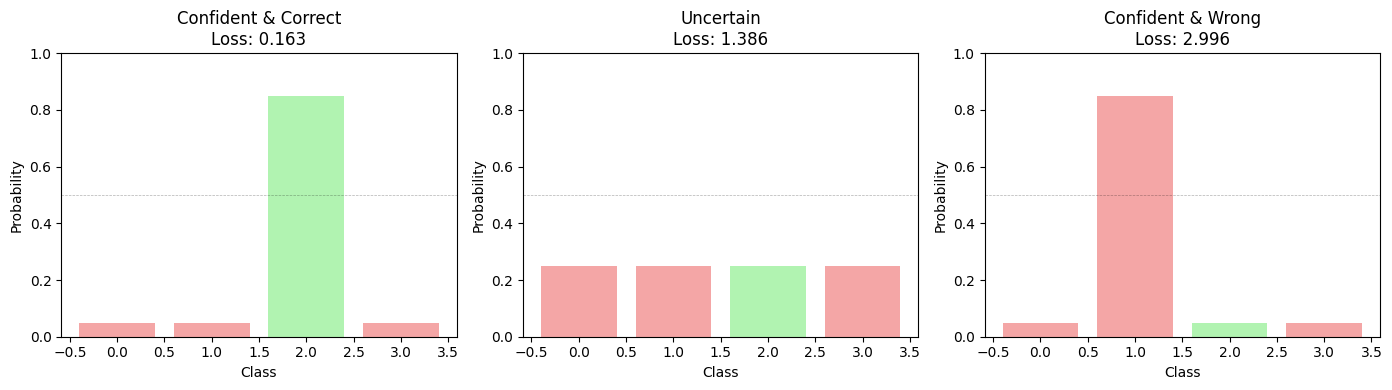

In [8]:
# Let's see how loss changes with different predictions
true_class = 2

# Scenario 1: Model is confident and correct
pred_good = torch.tensor([0.05, 0.05, 0.85, 0.05])  # High prob on class 2
loss_good = -torch.log(pred_good[true_class])

# Scenario 2: Model is uncertain
pred_uncertain = torch.tensor([0.25, 0.25, 0.25, 0.25])  # Equal probs
loss_uncertain = -torch.log(pred_uncertain[true_class])

# Scenario 3: Model is confident but wrong
pred_bad = torch.tensor([0.05, 0.85, 0.05, 0.05])  # High prob on class 1 (wrong!)
loss_bad = -torch.log(pred_bad[true_class])

print(f"True class: {true_class}\n")
print(f"Scenario 1 - Confident & Correct: {pred_good.tolist()}")
print(f"  Loss: {loss_good:.4f} (low is good!)\n")

print(f"Scenario 2 - Uncertain: {pred_uncertain.tolist()}")
print(f"  Loss: {loss_uncertain:.4f}\n")

print(f"Scenario 3 - Confident & Wrong: {pred_bad.tolist()}")
print(f"  Loss: {loss_bad:.4f} (high is bad!)\n")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
scenarios = [
    (pred_good, loss_good, "Confident & Correct"),
    (pred_uncertain, loss_uncertain, "Uncertain"),
    (pred_bad, loss_bad, "Confident & Wrong")
]

for ax, (pred, loss, title) in zip(axes, scenarios):
    colors = ['lightcoral' if i != true_class else 'lightgreen' for i in range(4)]
    ax.bar(range(4), pred.numpy(), color=colors, alpha=0.7)
    ax.set_xlabel('Class')
    ax.set_ylabel('Probability')
    ax.set_title(f"{title}\nLoss: {loss:.3f}")
    ax.set_ylim([0, 1])
    ax.axhline(y=0.5, color='k', linestyle='--', linewidth=0.5, alpha=0.3)

plt.tight_layout()
plt.show()

**Takeaway**: The loss is **lowest when we assign high probability to the true class** and doesn't directly care about the other probabilities (though they're constrained to sum to 1).

### PyTorch's Cross-Entropy Loss

PyTorch provides `nn.CrossEntropyLoss()` which:
1. **Combines softmax + categorical cross-entropy** in one operation (more numerically stable)
2. Takes **raw logits** as input (not probabilities!)
3. Expects true labels as class indices (not one-hot encoded)

This is the standard loss function for multiclass classification in PyTorch.

In [9]:
# PyTorch's CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# Raw logits (before softmax)
logits = torch.tensor([[2.0, 1.0, 0.1, 3.0]])  # Shape: (batch_size=1, num_classes=4)
true_label = torch.tensor([3])  # True class is 3, shape: (batch_size=1)

# Calculate loss
loss = criterion(logits, true_label)
print(f"CrossEntropyLoss: {loss:.4f}")

# Let's verify this matches our manual calculation
probs = F.softmax(logits, dim=1)
manual_loss = -torch.log(probs[0, true_label[0]])
print(f"Manual calculation: {manual_loss:.4f}")
print(f"\nThey match!")

CrossEntropyLoss: 0.4436
Manual calculation: 0.4436

They match!


## Building a Multiclass Classifier: Iris Dataset

Now let's put it all together! We'll build a simple MLP to classify iris flowers into 3 species.

### The Iris Dataset

- **Features**: 4 measurements (sepal length, sepal width, petal length, petal width)
- **Classes**: 3 species (Setosa, Versicolor, Virginica)
- **Samples**: 150 flowers (50 per species)

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load Iris dataset
iris = load_iris()
X = iris.data  # Shape: (150, 4)
y = iris.target  # Shape: (150,) with values 0, 1, 2

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(iris.target_names)}")
print(f"Class names: {iris.target_names}")
print(f"Feature names: {iris.feature_names}")

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (important for neural networks!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)  # LongTensor for class indices
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print(f"\nTraining samples: {X_train_tensor.shape[0]}")
print(f"Test samples: {X_test_tensor.shape[0]}")

Dataset shape: (150, 4)
Number of classes: 3
Class names: ['setosa' 'versicolor' 'virginica']
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Training samples: 120
Test samples: 30


### Step 1: Define the Model Architecture

We'll create a simple MLP with:
- **Input layer**: 4 features
- **Hidden layer**: 16 neurons with ReLU activation
- **Output layer**: 3 neurons (one per class, **no activation** - we'll use raw logits)

In [11]:
class IrisClassifier(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=16, output_dim=3):
        super(IrisClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)  # Input -> Hidden
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)  # Hidden -> Output (logits)
        # NOTE: No softmax here! CrossEntropyLoss expects raw logits

    def forward(self, x):
        # x shape: (batch_size, 4)
        x = self.fc1(x)      # (batch_size, 16)
        x = self.relu(x)     # (batch_size, 16)
        x = self.fc2(x)      # (batch_size, 3) - raw logits
        return x

# Create model instance
model = IrisClassifier()
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

IrisClassifier(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)

Total parameters: 131


**Important**: Notice we don't apply softmax in the `forward()` method. `CrossEntropyLoss` will handle that internally for numerical stability.

### Step 2: Define Loss Function and Optimizer

In [12]:
# Loss function (combines softmax + categorical cross-entropy)
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


### Step 3: Train the Model

We'll train for several epochs and track the loss.

In [13]:
# Training loop
num_epochs = 100
losses = []

model.train()  # Set model to training mode

for epoch in range(num_epochs):
    # Forward pass
    logits = model(X_train_tensor)  # Shape: (120, 3)
    loss = criterion(logits, y_train_tensor)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Record loss
    losses.append(loss.item())

    # Print progress every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")

print("\nTraining complete!")

Epoch [20/100], Loss: 0.3695
Epoch [40/100], Loss: 0.1923
Epoch [60/100], Loss: 0.1063
Epoch [80/100], Loss: 0.0724
Epoch [100/100], Loss: 0.0590

Training complete!


### Step 4: Visualize Training Progress

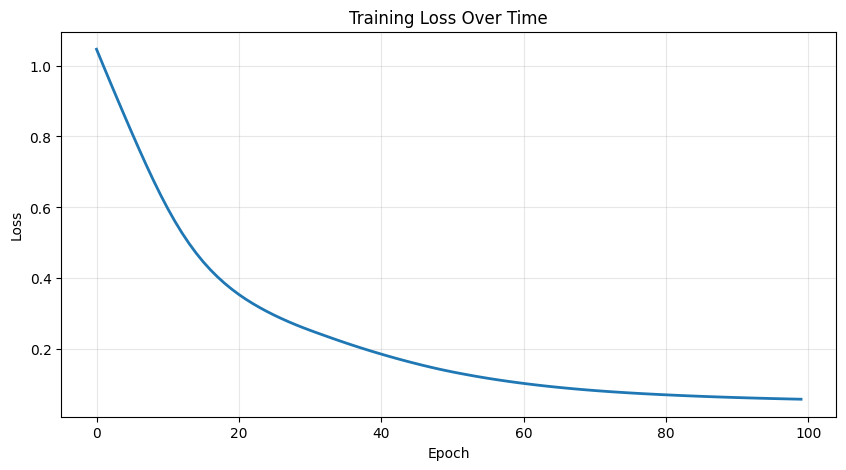

Final training loss: 0.0590


In [14]:
plt.figure(figsize=(10, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(alpha=0.3)
plt.show()

print(f"Final training loss: {losses[-1]:.4f}")

### Step 5: Evaluate on Test Set

To make predictions, we:
1. Get logits from the model
2. Apply `argmax` to find the class with highest logit (or probability)
3. Compare with true labels

In [15]:
model.eval()  # Set model to evaluation mode

with torch.no_grad():  # Disable gradient computation for inference
    # Get logits
    test_logits = model(X_test_tensor)  # Shape: (30, 3)

    # Get predicted classes (argmax of logits)
    predictions = torch.argmax(test_logits, dim=1)  # Shape: (30,)

    # Calculate accuracy
    correct = (predictions == y_test_tensor).sum().item()
    accuracy = correct / len(y_test_tensor)

    print(f"Test Accuracy: {accuracy * 100:.2f}%")
    print(f"Correct predictions: {correct}/{len(y_test_tensor)}")

Test Accuracy: 96.67%
Correct predictions: 29/30


### Step 6: Examine Individual Predictions

Let's look at some test examples and see the predicted probabilities.

In [16]:
# Look at first 5 test samples
with torch.no_grad():
    sample_logits = model(X_test_tensor[:5])
    sample_probs = F.softmax(sample_logits, dim=1)  # Convert logits to probabilities
    sample_preds = torch.argmax(sample_logits, dim=1)

print("Sample predictions:\n")
for i in range(5):
    true_class = y_test_tensor[i].item()
    pred_class = sample_preds[i].item()

    print(f"Sample {i+1}:")
    print(f"  True class: {true_class} ({iris.target_names[true_class]})")
    print(f"  Predicted: {pred_class} ({iris.target_names[pred_class]})")
    print(f"  Probabilities: {sample_probs[i].numpy()}")
    print(f"  Confidence: {sample_probs[i, pred_class]:.3f}")
    print()

Sample predictions:

Sample 1:
  True class: 0 (setosa)
  Predicted: 0 (setosa)
  Probabilities: [9.9937671e-01 6.1733875e-04 5.9456256e-06]
  Confidence: 0.999

Sample 2:
  True class: 2 (virginica)
  Predicted: 2 (virginica)
  Probabilities: [0.00241374 0.23246722 0.765119  ]
  Confidence: 0.765

Sample 3:
  True class: 1 (versicolor)
  Predicted: 1 (versicolor)
  Probabilities: [0.0354423  0.9602996  0.00425811]
  Confidence: 0.960

Sample 4:
  True class: 1 (versicolor)
  Predicted: 1 (versicolor)
  Probabilities: [0.01265624 0.98446065 0.00288314]
  Confidence: 0.984

Sample 5:
  True class: 0 (setosa)
  Predicted: 0 (setosa)
  Probabilities: [9.9976295e-01 2.3396751e-04 3.0702929e-06]
  Confidence: 1.000



### Visualizing the Predictions

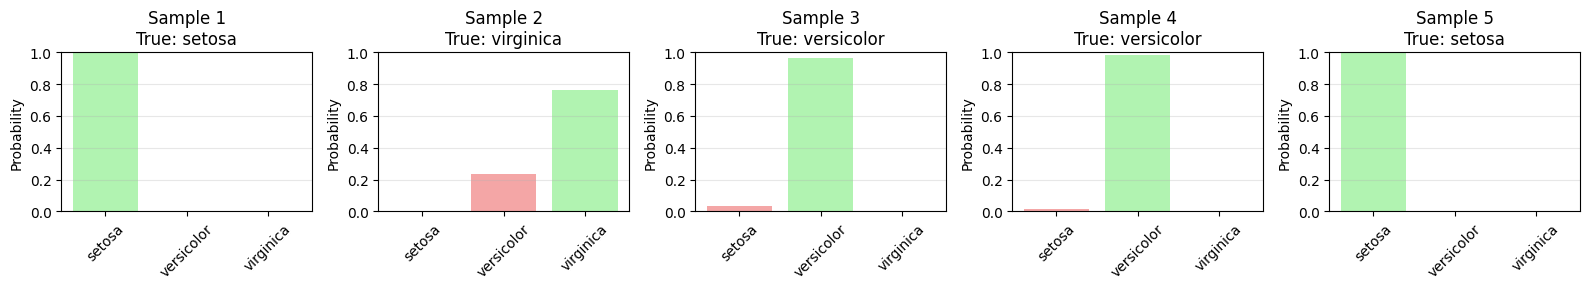

In [17]:
# Visualize probability distributions for first 5 test samples
fig, axes = plt.subplots(1, 5, figsize=(16, 3))

for i, ax in enumerate(axes):
    true_class = y_test_tensor[i].item()
    pred_class = sample_preds[i].item()
    probs = sample_probs[i].numpy()

    # Color code: green if correct, red if wrong
    colors = ['lightgreen' if j == true_class else 'lightcoral' for j in range(3)]

    ax.bar(iris.target_names, probs, color=colors, alpha=0.7)
    ax.set_ylim([0, 1])
    ax.set_ylabel('Probability')
    ax.set_title(f'Sample {i+1}\nTrue: {iris.target_names[true_class]}')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 🔧 Mini-Exercise 3: Model Experimentation

**TODO**: Try improving the model's performance by:
1. Changing the hidden layer size (try 8, 32, or 64 neurons)
2. Adjusting the learning rate (try 0.001 or 0.1)
3. Training for more epochs (try 200 or 500)

**What to observe**: How do these changes affect:
- Training loss curve
- Final test accuracy
- Training speed

⏱️ ~10 minutes

In [ ]:
# TODO: Create and train a new model with different hyperparameters
# Example:
# model_v2 = IrisClassifier(input_dim=4, hidden_dim=32, output_dim=3)
# optimizer_v2 = optim.Adam(model_v2.parameters(), lr=0.001)
# ... train and evaluate ...


## Summary

In this notebook, we learned:

1. **Why we need softmax**: Binary classification (sigmoid) doesn't work for 3+ classes

2. **Softmax function**: Converts arbitrary logits into a valid probability distribution
   - Outputs sum to 1
   - All outputs between 0 and 1
   - Preserves order of logits

3. **Categorical Cross-Entropy**: Generalization of binary cross-entropy
   - Only the term for the true class is active
   - Penalizes low probability on the correct class

4. **PyTorch implementation**:
   - `nn.CrossEntropyLoss()` combines softmax + loss (expects logits, not probabilities)
   - Output layer should have `num_classes` neurons with **no activation**
   - Use `F.softmax()` only for inference/visualization

5. **Building a classifier**: Successfully trained an MLP on the Iris dataset

### Next Steps

With multiclass classification mastered, we can now tackle more complex datasets like MNIST and CIFAR-10. In upcoming notebooks, we'll explore:
- Convolutional Neural Networks (CNNs) for image classification
- Deeper architectures and regularization techniques
- Advanced optimization strategies